* DARPA hosts: weighting: `total_event_count` from the per-host activity-evolution ledger — sum of CDM events whose record carried that cmdline.
* HPC login: weighting: sum of read+write syscall deltas (`syscr + syscw`) per process from `capture_proc_io` TSVs, attributed to the process's `comm` (executable name from `/proc/<pid>/comm`). 

In [7]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from provenance_explorer.analysis.activity_realism.activity_evolution.cmdline_normalization import (
    normalize,
)
from provenance_explorer.plotting.config import apply_style, palette
from provenance_explorer.registry.registry_all import CACHE_ROOT, FIGURES_ROOT, REPO_ROOT

apply_style()

HPC_IO_DIR = REPO_ROOT / "scripts" / "hpc_monitoring" / "capture_io" / "capture_proc"
HPC_RANGE_LO = "20260320_14"
HPC_RANGE_HI = "20260324_14"

## Series configuration

In [8]:
@dataclass
class Series:
    label: str
    ds: str
    subds: str
    host_id: str | None

DARPA_SERIES = [
    Series("E5 Cadets #1", "e5", "cadets", "A3702F4C-5A0C-11E9-B8B9-D4AE52C1DBD3"),
    Series("E5 Cadets #2", "e5", "cadets", "CB02303B-654E-11E9-A80C-6C2B597E484C"),
    Series("E5 Cadets #3", "e5", "cadets", "3A541941-5B04-11E9-B2DB-D4AE52C1DBD3"),
    Series("E5 Theia #1", "e5", "theia",  "37345038-89F2-5899-8FD2-B6D0844A7DBF"),
    Series("E5 Theia #2", "e5", "theia",  "C75CAC93-0BE3-5D8A-9540-A1F43574DE25"),
    Series("E5 Theia #3", "e5", "theia",  "81286EE1-D2EB-53D8-AEAB-DB2728F9FB0F"),
    Series("E5 Trace #1", "e5", "trace",  "7A665024-F3E3-3D4E-3A98-D9651E351DE4"),
    Series("E5 Trace #2", "e5", "trace",  "DF4AF963-C31C-DAFC-B5C6-D86F33322775"),
    Series("E5 Trace #3", "e5", "trace",  "952CC6C6-39F9-AE40-7052-38052B1E5D21"),
]
HPC_LABEL = "HPC Login"
ALL_LABELS = [s.label for s in DARPA_SERIES] + [HPC_LABEL]

## Taxonomy

In [9]:
CATEGORIES: list[tuple[str, list[str]]] = [
    ("Shells & sessions", [
        r"^(bash|sh|csh|tcsh|zsh|ksh|dash|fish)$",
        r"^(tmux|screen|byobu|mosh|mosh-server)$",
        r"^\(sd-pam\)$",
        r"^(fortune|resizewin|motd.*|login|logname)$",
        r"^(xterm|uxterm|gnome-terminal|konsole|terminator|alacritty|kitty|st)$",
    ]),
    ("GUI / desktop apps", [
        r"^(firefox|thunderbird|chromium|chrome|google-chrome|opera|brave)$",
        r"^pulseaudio$",
        r"^indicator-.*",
        r"^xfce4-.*", r"^xf(settingsd|desktop|run4|wm4)$",
        r"^xscreensaver.*", r"^xrdb$", r"^xinit$", r"^xsession$", r"^xrandr$",
        r"^(fuzzyflakes|fiberlamp|glmatrix|flurry|substrate|gltext|glschool|glcells|hypertorus)$",
        r"^(Thunar|nautilus|dolphin|pcmanfm|caja)$",
        r"^exo-.*",
        r"^(gnome-.*|kde-.*|plasma.*|kdeinit.*|gvfs.*|gdbus|gconfd.*|gsettings|gcalctool)$",
        r"^(console-kit-daemon|ck-.*|udev-acl\.ck)$",
        r"^(evolution|gedit|kate|libreoffice.*|soffice.*|vlc|mpv|totem|rhythmbox|evince)$",
        r"^(crashreporter|minidump-analyzer)$",
    ]),
    ("Coreutils & text", [
        r"^(sed|awk|gawk|grep|egrep|fgrep|cat|cut|tr|sort|uniq|head|tail|wc|tee|paste|join|fold)$",
        r"^(ls|find|locate|stat|file|du|df|readlink|basename|dirname|realpath|tree)$",
        r"^(env|mkdir|rmdir|rm|mv|cp|touch|ln|chmod|chown|chgrp|install|chattr|lsattr)$",
        r"^(date|uname|whoami|who|id|users|groups|hostname|tty|pwd|getent|locale)$",
        r"^(mktemp|sleep|echo|printf|expr|test|true|false|yes|seq|bc|dc|xargs|nohup|nice|ionice|timeout|jot)$",
        r"^(dd|sync|fsync|cmp|diff|patch|md5sum|sha\d+sum|tar|gzip|gunzip|bzip2|xz|zip|unzip|pigz|split)$",
        r"^ldconfig.*",
        r"^(top|htop|atop|iftop|iotop|free|uptime|vmstat|iostat|mpstat|sar|pidstat|dstat|nload|nethogs|ps|lsof|pmap|fuser|pgrep|pkill|kill|killall)$",
        r"^(netstat|ss|ifconfig|ip|route|arp|ping|ping6|traceroute|nslookup|dig|host|tcpdump|ngrep|nc|netcat|ncat|socat)$",
        r"^(dmesg|kldstat|kenv|pciconf|swapinfo|lspci|lsusb|lsblk|lscpu|lsmod|kmod)$",
        r"^(openssl|base64|hexdump|od|strings|hd)$",
        r"^(unlink|getfacl|setfacl|utempter|msgs)$",
        r"^(dircolors|clear|clear_console|reset|tput|stty|setterm|tset)$",
        r"^(watch|less|more|man|info|whatis|apropos|which|whereis|type)$",
        r"^(mc|rg|fd|fzf|bat|exa|jq|yq)$",
        r"^(lockf|flock)$",
    ]),
    ("Dev / build / IDE", [
        r"^(cc|c\+\+|gcc|g\+\+|clang|clang\+\+|ld|ar|as|ranlib|nm|strip|objdump|objcopy|gdb|lldb|valgrind)$",
        r"^(make|gmake|cmake|cmake3|ninja|automake|autoconf|libtool|pkg-config|m4|bison|flex|yacc)$",
        r"^(cargo|rustc|cargo-.*)$",
        r"^(python|python\d.*|platform-python|ipython|jupyter.*)$",
        r"^(node|npm|nodejs|yarn|pnpm)$",
        r"^(cpptools.*|code|code-.*|vscode.*|language_server.*)$",
        r"^(perl|ruby|java|javac|go|gem|composer|php|R|julia|scala|kotlin|swift|lua|ocaml)$",
        r"^(git|svn|hg|cvs|bzr|gh|gk|claude|codex|pet)$",
        r"^(vi|vim|nvim|emacs.*|nano|pico|ed|jed|joe|ne|micro)$",
        r"^(ansys.*|matlab|octave|gnuplot|mathematica|wolfram|fluent.*|cortex.*)$",
        r"^(apptainer|Apptainer|singularity|docker|podman|buildah|skopeo|faked)$",
        r"^(gen_.*|fastp|regtools|hydra_pmi_proxy)$",  # user-built research binaries on HPC
        r"^main$",
    ]),
    ("Package management", [
        r"^(apt|apt-get|apt-config|apt-key|apt-cache|aptitude)$",
        r"^dpkg.*",
        r"^(dnf|yum|rpm|zypper|pacman|pkg|pip|pip\d.*|)$",
        r"^(mandb|update-.*|run-parts|dh_.*|debconf.*|select-editor)$",
        r"^http$",  # apt http transport method
    ]),
    ("Remote access & file transfer", [
        r"^sshd.*",
        r"^(ssh|scp|sftp|sftp-server|ssh-agent|ssh-keygen|ssh-keyscan|rsync)$",
        r"^(ftp|wget|curl|lftp)$",
    ]),
    ("Mail & messaging", [
        r"^(sendmail|postfix|master|qmgr|pickup|smtpd|smtp|local|cleanup|trivial-rewrite|bounce|tlsmgr|anvil|scache|exim|dovecot|opendkim|opendmarc|spamd)$",
        r"^(mail|mail\.local|mailx|mutt|pine|alpine|elm|mailq|hoststat)$",
    ]),
    ("System services & daemons", [
        r"^(systemd|systemd-.*|init|upstart|launchd|initctl|reload)$",
        r"^(dbus-daemon|dbus|polkitd|polkit|udevd|systemd-udevd|elogind|rtkit-daemon|accounts-daemon)$",
        r"^(irqbalance|auditd|chronyd|ntpd|ntpdate|smartd|cron|crond|CRON|anacron|atd|atrun)$",
        r"^(gssproxy|sssd|sssd_.*|nscd|nslcd|munge|munged|rpc\..*|rpcbind|nfsd|mountd|cachefilesd|cifsd|smbd|nmbd|winbindd)$",
        r"^(agetty|getty|mingetty|sudo|su|pkexec|pam_.*|sssd-.*)$",
        r"^(chsh|wall|write|usermod|useradd|userdel|passwd|groupmod|groupadd|groupdel)$",
        r"^(sysctl|modprobe|insmod|rmmod|swapon|mount|umount|losetup|fdisk|parted|dumpe2fs|tune2fs|e2fsck|fsck|mkfs.*|blkid)$",
        r"^(slurm.*|pbsdsh|qstat|qsub|sbatch|salloc|srun|scontrol|sinfo|squeue|sbalance|scancel|mpirun|mpiexec)$",
        r"^(pfctl|iptables|ip6tables|firewalld|ufw|nft|conntrack|fail2ban.*)$",
        r"^(NetworkManager|wpa_supplicant|dhclient|dhclient3|dhcpd|dhcpcd|systemd-networkd|systemd-resolved|named|bind|unbound|dnsmasq|avahi.*|avahi-autoipd)$",
        r"^(rsyslog|rsyslogd|syslog-ng|journald|systemd-journald|logrotate|newsyslog|dlogd|klogd|syslog.*)$",
        r"^(kworker.*|u:\d+|ksoftirqd|kthreadd|migration|rcu_.*|watchdog|khugepaged|kswapd|kcompactd)$",
        r"^(alloy|rdma-ndd|wwclient|mcelog|node_exporter|prometheus|grafana|telegraf|collectd)$",
        r"^(start-stop-daemon|systemctl|service|svcs|launchctl|rcctl)$",
        r"^(adjkerntz|hwclock|acpi_available|acpid)$",
        r"^(ubuntu-geoip-provider|geoip.*)$",
    ]),
]

_COMPILED = [(name, [re.compile(p) for p in pats]) for name, pats in CATEGORIES]
CATEGORY_ORDER = [name for name, _ in CATEGORIES] + ["Other"]

def categorize(basename: str) -> str:
    for name, pats in _COMPILED:
        if any(p.match(basename) for p in pats):
            return name
    return "Other"

def basename_of(cmd: str) -> str:
    cmd = cmd.strip()
    if not cmd:
        return ""
    tok = cmd.split()[0].lstrip("-")
    if "/" in tok:
        tok = tok.rsplit("/", 1)[-1]
    return tok

## Per-host weighted basenames

In [10]:
def darpa_basename_weights(s: Series) -> pd.DataFrame:
    p = CACHE_ROOT / f"activity_evolution_plot/{s.ds}/{s.subds}/activity_evolution.parquet"
    df = pd.read_parquet(p)
    df = df[df.host_id == s.host_id].copy()
    df["norm"] = df["normalised_cmdline"].astype(str).map(
        lambda c: normalize(c, s.ds, s.subds)
    )
    df = df.groupby("norm", as_index=False).agg(weight=("total_event_count", "sum"))
    df["basename"] = df["norm"].map(basename_of)
    return df.groupby("basename", as_index=False)["weight"].sum()


def hpc_basename_weights() -> pd.DataFrame:
    """Sum per-(pid, comm) syscr+syscw deltas per cmd across the HPC capture window."""
    pat = re.compile(r"(\d{8}_\d{2})")
    def stem(p: Path) -> str:
        m = pat.search(p.name)
        return m.group(1) if m else ""

    files = sorted(
        f for f in HPC_IO_DIR.glob("io_*.tsv")
        if HPC_RANGE_LO <= stem(f) <= HPC_RANGE_HI
    )
    frames = []
    for f in files:
        d = pd.read_csv(
            f, sep="\t",
            usecols=["sample_ts", "pid", "comm", "syscr", "syscw"],
            dtype={
                "sample_ts": "int64", "pid": "int64", "comm": "string",
                "syscr": "int64", "syscw": "int64",
            },
        )
        frames.append(d)
    io = pd.concat(frames, ignore_index=True)
    io = io.sort_values(["pid", "comm", "sample_ts"]).reset_index(drop=True)

    # New track whenever (pid, comm) changes => deltas computed within track only.
    track = (
        io["pid"].ne(io["pid"].shift()) | io["comm"].ne(io["comm"].shift())
    ).cumsum()
    io["d_syscr"] = io.groupby(track)["syscr"].diff()
    io["d_syscw"] = io.groupby(track)["syscw"].diff()
    io = io.dropna(subset=["d_syscr", "d_syscw"]).copy()
    io[["d_syscr", "d_syscw"]] = io[["d_syscr", "d_syscw"]].clip(lower=0)
    io["rw"] = (io["d_syscr"] + io["d_syscw"]).astype("int64")

    agg = io.groupby("comm", as_index=False)["rw"].sum()
    agg.columns = ["basename", "weight"]
    return agg


host_weights: dict[str, pd.DataFrame] = {}
for s in DARPA_SERIES:
    host_weights[s.label] = darpa_basename_weights(s)
host_weights[HPC_LABEL] = hpc_basename_weights()

for h, df in host_weights.items():
    print(f"{h:<14}  unique basenames={len(df):>4}")

E5 Cadets #1    unique basenames= 116
E5 Cadets #2    unique basenames= 119
E5 Cadets #3    unique basenames= 116
E5 Theia #1     unique basenames= 239
E5 Theia #2     unique basenames= 237
E5 Theia #3     unique basenames= 270
E5 Trace #1     unique basenames= 184
E5 Trace #2     unique basenames= 185
E5 Trace #3     unique basenames= 159
HPC Login       unique basenames=2869


## per-host category shares

In [11]:
def host_category_shares(weights: pd.DataFrame) -> pd.Series:
    weights = weights.copy()
    weights["category"] = weights["basename"].map(categorize)
    by_cat = weights.groupby("category")["weight"].sum()
    total = by_cat.sum()
    return (by_cat / total).reindex(CATEGORY_ORDER, fill_value=0.0)

shares = pd.DataFrame(
    {h: host_category_shares(host_weights[h]) for h in ALL_LABELS},
    index=CATEGORY_ORDER,
)

## plot

wrote /mnt/vast-nhr/home/j.rieling/u20606/provenance-benchmark-explorer/img/figures/cmdline_categories/figure.pdf


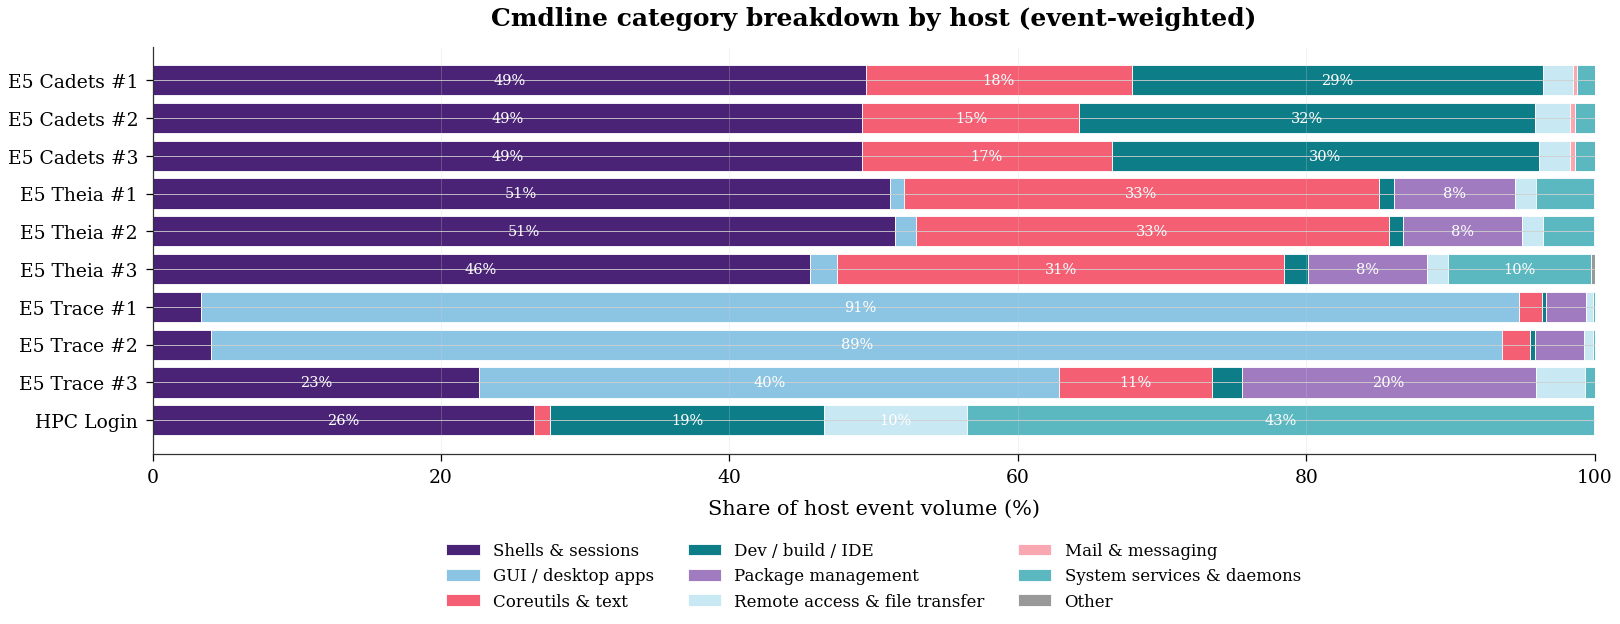

In [12]:
_pal = palette()
CAT_COLORS = {cat: _pal[i % len(_pal)] for i, cat in enumerate(CATEGORY_ORDER[:-1])}
CAT_COLORS["Other"] = "0.6"  # neutral grey for Other

fig, ax = plt.subplots(figsize=(11, 4.5))

y_pos = np.arange(len(ALL_LABELS))
left = np.zeros(len(ALL_LABELS))
for cat in CATEGORY_ORDER:
    vals = shares.loc[cat, ALL_LABELS].values * 100
    ax.barh(y_pos, vals, left=left, label=cat, color=CAT_COLORS[cat], edgecolor="white", linewidth=0.4)
    # Annotate segments >= 5%
    for i, v in enumerate(vals):
        if v >= 5:
            ax.text(left[i] + v / 2, y_pos[i], f"{v:.0f}%",
                    ha="center", va="center", fontsize=7,
                    color="white" if cat != "Other" else "black")
    left += vals

ax.set_yticks(y_pos)
ax.set_yticklabels(ALL_LABELS)
ax.invert_yaxis()  # first host on top
ax.set_xlim(0, 100)
ax.set_xlabel("Share of host event volume (%)")
ax.set_title("Cmdline category breakdown by host (event-weighted)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=8, frameon=False)
ax.grid(True, axis="x", alpha=0.3)

fig.tight_layout()

out_dir = Path(FIGURES_ROOT) / "cmdline_categories"
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "figure.pdf", bbox_inches="tight")
fig.savefig(out_dir / "figure.png", dpi=200, bbox_inches="tight")
print(f"wrote {out_dir / 'figure.pdf'}")
plt.show()